# ------------------- Importaciones

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display
from sklearn.neural_network import MLPClassifier

In [2]:
# carha del archivo y revision del df

data = pd.read_csv(r"bank_marketing_RETO_DS_AS.csv")

"""primero para revisar la integridad del archivo"""
print(data.head(10))

   age            job  marital  education default  balance housing loan  \
0   31  self-employed  married   tertiary      no     2666      no   no   
1   29     unemployed   single    unknown      no     1584      no   no   
2   41    blue-collar  married  secondary      no     2152     yes   no   
3   50    blue-collar  married  secondary      no       84     yes   no   
4   40         admin.  married  secondary      no        0      no   no   
5   58        retired  married  secondary      no     8332      no   no   
6   36       services   single  secondary      no      198     yes   no   
7   26     technician   single  secondary      no     1231     yes   no   
8   34    blue-collar  married    primary      no     2320     yes   no   
9   26     management   single   tertiary      no       47     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome    y  
0  cellular   10   nov       318         2     97         6  success  yes  
1  cellular    6   sep

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB
None


In [4]:
print(data.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [5]:
print(data.shape)

(9000, 17)


In [6]:
#datos analiticos
print(data.describe())

               age       balance          day     duration     campaign  \
count  9000.000000   9000.000000  9000.000000  9000.000000  9000.000000   
mean     41.090556   1482.262778    15.619556   353.832778     2.520111   
std      11.664253   3031.013197     8.345305   336.945158     2.737758   
min      18.000000  -3058.000000     1.000000     3.000000     1.000000   
25%      32.000000    109.000000     8.000000   131.000000     1.000000   
50%      39.000000    519.000000    15.000000   240.500000     2.000000   
75%      49.000000   1646.500000    21.000000   462.000000     3.000000   
max      95.000000  81204.000000    31.000000  3253.000000    58.000000   

             pdays     previous  
count  9000.000000  9000.000000  
mean     50.511333     0.788889  
std     107.691963     2.210273  
min      -1.000000     0.000000  
25%      -1.000000     0.000000  
50%      -1.000000     0.000000  
75%      -1.000000     0.000000  
max     850.000000    58.000000  


In [7]:
#verificacion de celdas vacias, aunque en este caso se use la palabra "unkwown" para los datos que no se saben
print(data.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [8]:
#para los unkwown
print("unknown")
for columna in data.columns[data.dtypes == object]:
    n_unknown = (data[columna] == "unknown").sum()
    print(f"{columna}: {n_unknown}")
    
print(pd.crosstab(data["poutcome"], data["pdays"] == -1))
#hay 6781 unknowns en poutcome

unknown
job: 51
marital: 0
education: 377
default: 0
housing: 0
loan: 0
contact: 1982
month: 0
poutcome: 6783
y: 0
pdays     False  True 
poutcome              
failure    1006      0
other       441      0
success     770      0
unknown       2   6781


los datos perdidos estan en job = 51, education = 377, contact = 1982 y poutcome = 6783. no se hace dropna porque se perderia poutcome. unknown en poutcome significa que el cliente no fue contactado antes por lo cual nos sirve como una variable categorica

# ------------------- tipos de variables

In [9]:
"""las variables con menos de 20 valores distintos se consideran categoricas"""
print(data.nunique())

age            74
job            12
marital         3
education       4
default         2
balance      3476
housing         2
loan            2
contact         3
day            31
month          12
duration     1327
campaign       34
pdays         437
previous       31
poutcome        4
y               2
dtype: int64


In [10]:
num_cols = [c for c in data.columns if data[c].dtype != object and data[c].nunique() >= 20]
cat_cols = [c for c in data.columns if c not in num_cols]

print("numericas:", len(num_cols), num_cols)
print("categoricas:", len(cat_cols), cat_cols)

numericas: 7 ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categoricas: 10 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [11]:
# ------------------- variable de salida

print(data["y"].value_counts())
print("No: %.1f" % (100 * sum(data["y"] == "no") / data.shape[0]))
print("Si: %.1f" % (100 * sum(data["y"] == "yes") / data.shape[0]))

modelo_base = sum(data["y"] == "no") / data.shape[0]
print(f"modelo base: {modelo_base:.3f}")


y
no     5213
yes    3787
Name: count, dtype: int64
No: 57.9
Si: 42.1
modelo base: 0.579


5213 clientes no adquirieron el plan y 3787 si. se tiene 57.9% de exactitud, eso me quiere decir que todos los modelos tienen que superar ese porcentaje.

# ------------------- histograma para ver la distribucion


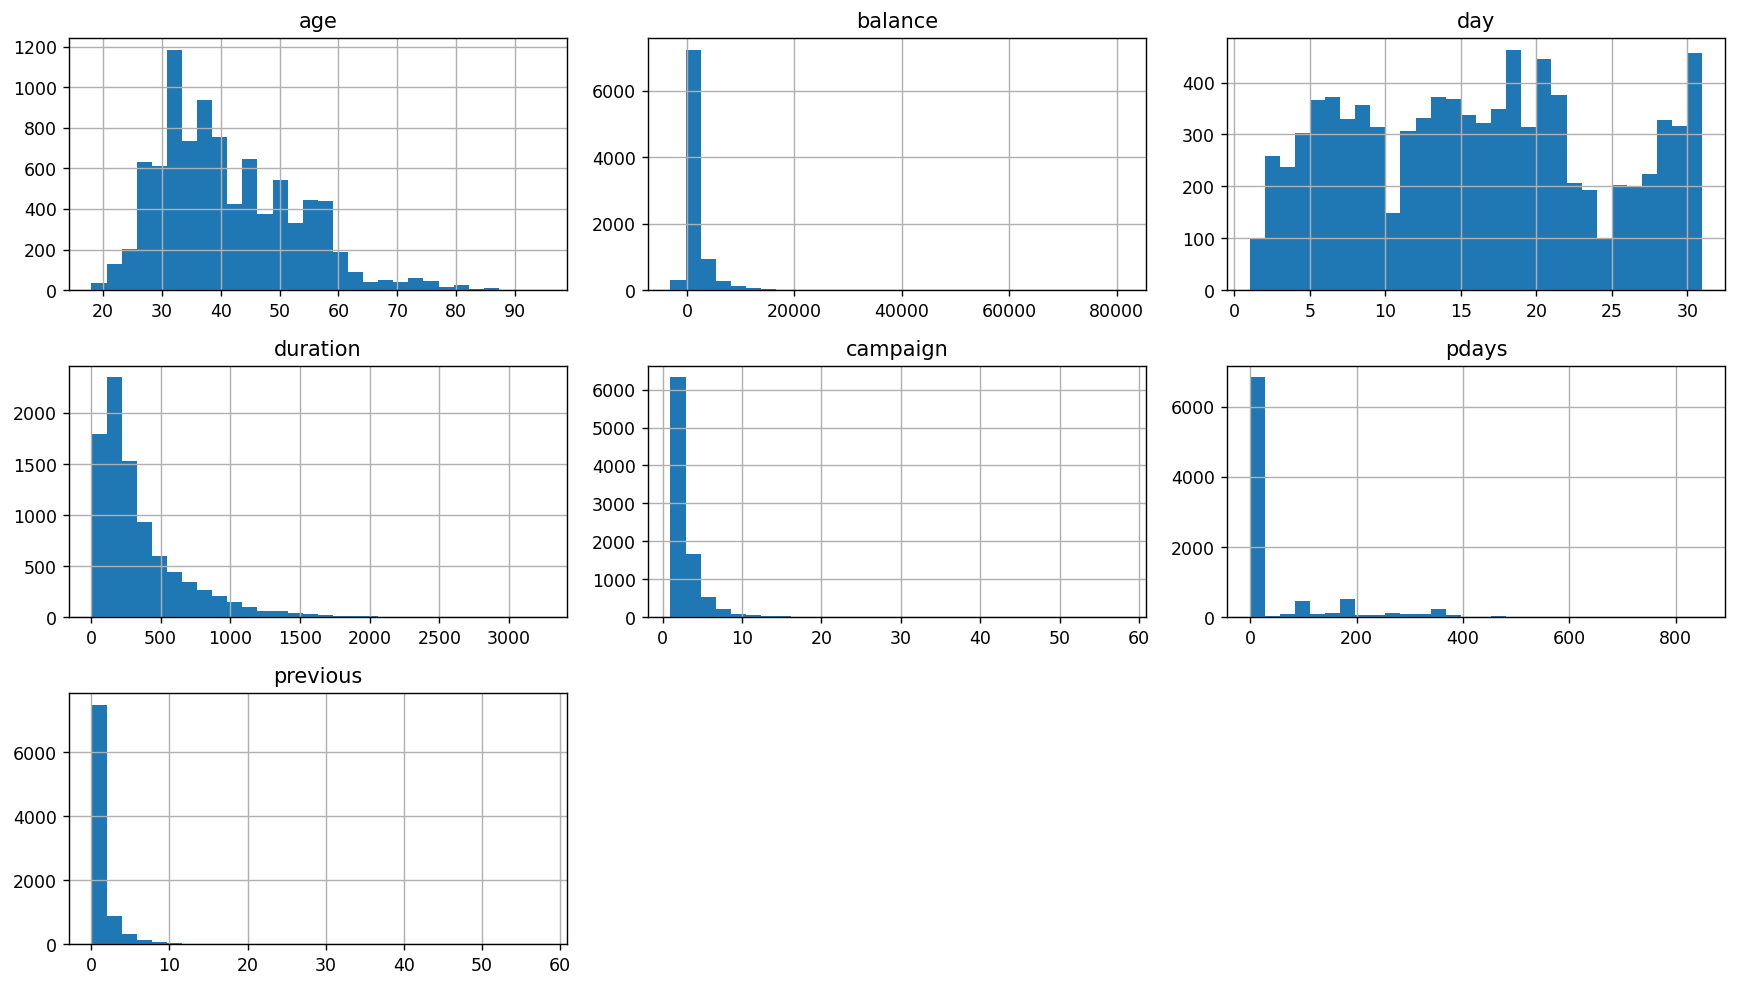

In [12]:
data[num_cols].hist(bins=30, figsize=(14, 8))
plt.tight_layout()
plt.show()

balance, duration, campaign, pdays y previous tienen sesgo positivo, no son acampanadas como pide la regresion logistica

# -------------------# transformacion de datos categoricos y numericos

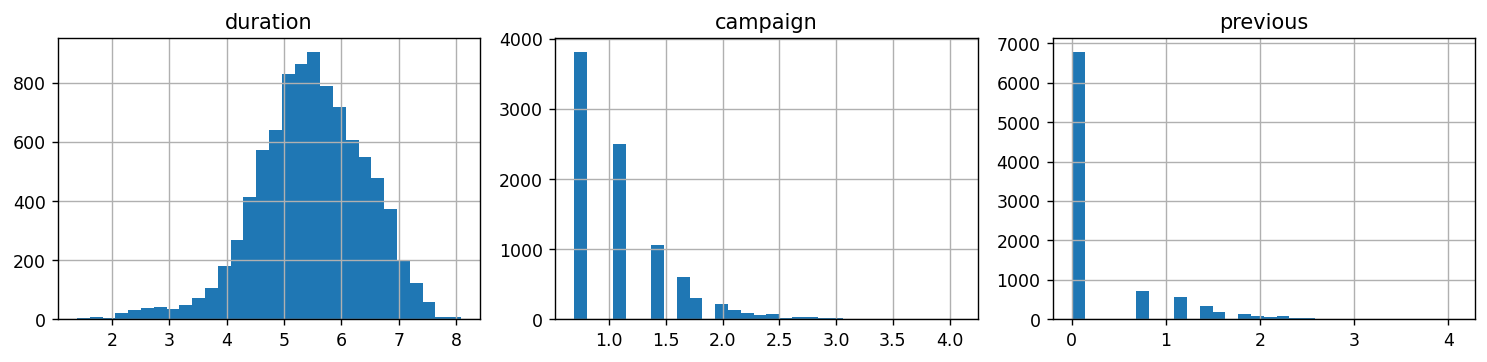

In [13]:
#copia del df para el modelo
df_model = data.copy()

"""para el sesgo positivo se aplica una transformacion logaritmica. se usa log(1 + x) en duration, campaign y previous porque son no negativas y tienen ceros"""
sesgadas = ["duration", "campaign", "previous"]
for col in sesgadas:
    df_model[col] = np.log1p(df_model[col])

df_model[sesgadas].hist(bins=30, figsize=(12, 3), layout=(1, 3))
plt.tight_layout()
plt.show()


despues del logaritmo duration y campaign se ven mejores, mas simetricas, a excepcion de previous que sigue teniendo muchos 0

In [14]:
"""las binarias (yes/no): default, housing, loan y (y) se pasan a 1:yes/0:no. la clase 1 ha adquirio el plan."""
binarias = ["default", "housing", "loan", "y"]
for columna in binarias:
    df_model[columna] = (df_model[columna] == "yes").astype(int)

In [15]:
"""las categoricas con mas de dos niveles se pasan a OHEncoder. drop_first=True sirve para evitar repetir la info. no se usa LabelEncoder porque le asigna un entero a cada nivel (0, 1, 2...) y eso le inventa un orden a variables que no lo tienen, como job o month, y la regresion logistica y la red neuronal tomarian ese orden como si fuera real. con OHEncoder cada nivel es una columna 0/1 y ninguno vale mas que otro"""
multiclase = ["job", "marital", "education", "contact", "month", "poutcome"]
df_model = pd.get_dummies(df_model, columns=multiclase, drop_first=True, dtype=int)

In [16]:
#revisar
print(df_model.shape)
print(df_model.head())
"""7 numericas, 3 binarias y 32 dummies mas la variable de salida."""

X = df_model.drop(columns="y")
y = df_model["y"]


(9000, 43)
   age  default  balance  housing  loan  day  duration  campaign  pdays  \
0   31        0     2666        0     0   10  5.765191  1.098612     97   
1   29        0     1584        0     0    6  5.505332  0.693147     -1   
2   41        0     2152        1     0   17  5.913503  0.693147     -1   
3   50        0       84        1     0   17  2.944439  2.197225     -1   
4   40        0        0        0     0   28  6.208590  1.098612    182   

   previous  ...  month_jul  month_jun  month_mar  month_may  month_nov  \
0  1.945910  ...          0          0          0          0          1   
1  0.000000  ...          0          0          0          0          0   
2  0.000000  ...          0          0          0          0          1   
3  0.000000  ...          1          0          0          0          0   
4  2.484907  ...          1          0          0          0          0   

   month_oct  month_sep  poutcome_other  poutcome_success  poutcome_unknown  
0        

# ------------------- Particion en entrenamiento, validacion y prueba


se elige 60 entrenamiento, 20 validacion y 20 prueba, con train_test_split como en las lecciones. stratify mantiene la misma proporcion de (si/no) en los tres conjuntos y los pesos se calculan con entrenamiento, los hiperparametros se escogen con validacion y prueba solo se usa al final

In [17]:
x_train, x_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=11, stratify=y)
x_validation, x_test, y_validation, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=11, stratify=y_temp)

print(x_train.shape, x_validation.shape, x_test.shape)
print(y_train.mean(), y_validation.mean(), y_test.mean())

(5400, 42) (1800, 42) (1800, 42)
0.42074074074074075 0.42055555555555557 0.4211111111111111


# ------------------- estandarizacion -> (x - media) / desviacion


In [18]:
def fun2(X, media, desv):
    return (X - media) / desv

"""la media y la desviacion se calculan solo con entrenamiento y se aplican igual a validacion y prueba"""
media = x_train[num_cols].mean()
desv = x_train[num_cols].std()

x_train = x_train.copy()
x_validation = x_validation.copy()
x_test = x_test.copy()
x_train[num_cols] = fun2(x_train[num_cols], media, desv)
x_validation[num_cols] = fun2(x_validation[num_cols], media, desv)
x_test[num_cols] = fun2(x_test[num_cols], media, desv)

print(x_train[num_cols].describe().round(2))


           age  balance      day  duration  campaign    pdays  previous
count  5400.00  5400.00  5400.00   5400.00   5400.00  5400.00   5400.00
mean      0.00     0.00     0.00      0.00     -0.00     0.00      0.00
std       1.00     1.00     1.00      1.00      1.00     1.00      1.00
min      -1.99    -1.49    -1.76     -4.27     -0.88    -0.49     -0.52
25%      -0.79    -0.45    -0.93     -0.64     -0.88    -0.49     -0.52
50%      -0.19    -0.32     0.03      0.02     -0.04    -0.49     -0.52
75%       0.67     0.06     0.75      0.71      0.55    -0.22      0.61
max       4.60    26.18     1.83      2.76      5.27     7.25      6.13


las variables numericas de entrenamiento quedan con media 0 y desviacion std 1 lo que me indica un buen rango

# ------------------- regresion logistica


In [19]:
"""primera aproximacion solver newton-cg y C=1.0"""
clf = LogisticRegression(C=1.0, solver="newton-cg", max_iter=1000)
modelo_RL = clf.fit(x_train, y_train)

print("regresion logistica:\naccuracy con el conjunto de validacion = ", modelo_RL.score(x_validation, y_validation))

pr = modelo_RL.predict(x_validation)
print(confusion_matrix(y_validation, pr))

regresion logistica:
accuracy con el conjunto de validacion =  0.8227777777777778
[[890 153]
 [166 591]]


In [20]:
#ajuste de hiperparametros: C
modelo_RL_tmp = LogisticRegression(C=0.2, penalty="l2", solver="lbfgs", max_iter=100, random_state=17)
modelo_RL_tmp.fit(x_train, np.ravel(y_train))
print("C=0.2, lbfgs, l2:", modelo_RL_tmp.score(x_validation, y_validation))

modelo_RL_hyper = LogisticRegression(C=0.1, penalty="l2", solver="lbfgs", random_state=5, max_iter=5)
modelo_RL_hyper.fit(x_train, np.ravel(y_train))
print("accuracy con max_iter=5 no converge, por lo tanto, no es confiable: %0.4f" % modelo_RL_hyper.score(x_validation, y_validation))

C=0.2, lbfgs, l2: 0.8177777777777778
accuracy con max_iter=5 no converge, por lo tanto, no es confiable: 0.8039


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed t

In [21]:
print("busqueda de C, solver y penalty")
resultados_RL = []
for solver, penalty in [("lbfgs", "l2"), ("newton-cg", "l2"), ("saga", "l2"), ("saga", "l1")]:
    for C in np.logspace(-5, 3, 9):
        clf = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000, random_state=17)
        clf.fit(x_train, np.ravel(y_train))
        tr, va = clf.score(x_train, y_train), clf.score(x_validation, y_validation)
        resultados_RL.append((solver, penalty, C, tr, va))
        print(f"solver={solver}, penalty={penalty}, C={C:g}: train={tr:.4f}, validacion={va:.4f}")

res_RL = pd.DataFrame(resultados_RL, columns=["solver", "penalty", "C", "train", "validacion"])
res_RL = res_RL.sort_values(["validacion", "C"], ascending=[False, True])
display(res_RL.head(5))

mejor_RL = res_RL.iloc[0]
print("mejor combinacion:", mejor_RL["solver"], mejor_RL["penalty"], "C =", mejor_RL["C"])

C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

busqueda de C, solver y penalty
solver=lbfgs, penalty=l2, C=1e-05: train=0.5793, validacion=0.5794
solver=lbfgs, penalty=l2, C=0.0001: train=0.5919, validacion=0.5928
solver=lbfgs, penalty=l2, C=0.001: train=0.7893, validacion=0.7822
solver=lbfgs, penalty=l2, C=0.01: train=0.8187, validacion=0.8067
solver=lbfgs, penalty=l2, C=0.1: train=0.8313, validacion=0.8194
solver=lbfgs, penalty=l2, C=1: train=0.8298, validacion=0.8222
solver=lbfgs, penalty=l2, C=10: train=0.8298, validacion=0.8222
solver=lbfgs, penalty=l2, C=100: train=0.8298, validacion=0.8233
solver=lbfgs, penalty=l2, C=1000: train=0.8300, validacion=0.8233
solver=newton-cg, penalty=l2, C=1e-05: train=0.5793, validacion=0.5794
solver=newton-cg, penalty=l2, C=0.0001: train=0.5919, validacion=0.5928
solver=newton-cg, penalty=l2, C=0.001: train=0.7893, validacion=0.7822
solver=newton-cg, penalty=l2, C=0.01: train=0.8187, validacion=0.8067


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

solver=newton-cg, penalty=l2, C=0.1: train=0.8315, validacion=0.8194
solver=newton-cg, penalty=l2, C=1: train=0.8302, validacion=0.8228
solver=newton-cg, penalty=l2, C=10: train=0.8298, validacion=0.8233
solver=newton-cg, penalty=l2, C=100: train=0.8298, validacion=0.8233
solver=newton-cg, penalty=l2, C=1000: train=0.8298, validacion=0.8233
solver=saga, penalty=l2, C=1e-05: train=0.5793, validacion=0.5794
solver=saga, penalty=l2, C=0.0001: train=0.5919, validacion=0.5928
solver=saga, penalty=l2, C=0.001: train=0.7893, validacion=0.7822


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

...

solver=saga, penalty=l1, C=100: train=0.8296, validacion=0.8233


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


solver=saga, penalty=l1, C=1000: train=0.8296, validacion=0.8239


,solver,penalty,C,train,validacion
33,saga,l1,10.0,0.829630,0.823889
25,saga,l2,100.0,0.829630,0.823889
26,saga,l2,1000.0,0.829630,0.823889
35,saga,l1,1000.0,0.829630,0.823889
15,newton-cg,l2,10.0,0.829815,0.823333


mejor combinacion: saga l1 C = 10.0


In [22]:
print("busqueda de C alrededor del mejor")
resultados_C = []
for C in np.linspace(mejor_RL["C"] / 2, mejor_RL["C"] * 2, 9):
    clf = LogisticRegression(C=C, penalty=mejor_RL["penalty"], solver=mejor_RL["solver"], max_iter=1000, random_state=17)
    clf.fit(x_train, np.ravel(y_train))
    resultados_C.append((C, clf.score(x_validation, y_validation)))
    print(f"C={C:.4f}: validacion={resultados_C[-1][1]:.4f}")

mejor_C = max(resultados_C, key=lambda t: (t[1], -t[0]))[0]
print("mejor C en validacion:", mejor_C)

busqueda de C alrededor del mejor


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C=5.0000: validacion=0.8233


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C=6.8750: validacion=0.8233


...

C=16.2500: validacion=0.8239


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C=18.1250: validacion=0.8239


C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C=20.0000: validacion=0.8239
mejor C en validacion: 8.75


con C=0.2, lbfgs y l2 la exactitud en validacion es 0.8178 y con max_iter=5 sale 0.8039 pero no converge, por eso ese resultado no se toma en cuenta. en la busqueda, con C muy chico el modelo se regulariza de mas y se queda en 0.58-0.59 que se acerca mas al modelo inicial base, con (C=0.01) sube a 0.81 y desde (C=0.1) se estabiliza en 0.82. los tres solver dan casi lo mismo y l1 con saga tambien. la mejor validacion es 0.8239 (saga con l1 y C=10). la busqueda fina alrededor no cambia nada (0.8233 a 0.8239), el mejor es (C=8.75) train (0.830) y validacion (0.824) quedan muy cerca, asi que no hay sobre-entrenamiento. las diferencias entre combinaciones son de menos de un punto

In [23]:
modelo_RL = LogisticRegression(C=mejor_C, penalty=mejor_RL["penalty"], solver=mejor_RL["solver"], max_iter=1000, random_state=17)
modelo_RL.fit(x_train, np.ravel(y_train))

print("regresion logistica ajustada: exactitud validacion =", modelo_RL.score(x_validation, y_validation))
print(confusion_matrix(y_validation, modelo_RL.predict(x_validation)))

C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\sasor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


regresion logistica ajustada: exactitud validacion = 0.8238888888888889
[[893 150]
 [167 590]]


# ------------------- modelo 2: red nueronal (perceptron multicapa)

In [24]:
"""primera aproximacion con dos capas ocultas de 15 y 4 neuronas y max_iter=700, se mide con validacion y se ve su matriz de confusion."""
modelo_NN = MLPClassifier(hidden_layer_sizes=(15, 4), max_iter=700, random_state=42)
modelo_NN.fit(x_train, y_train)
print("red neuronal (15, 4): exactitud validacion =", modelo_NN.score(x_validation, y_validation))
print(confusion_matrix(y_validation, modelo_NN.predict(x_validation)))

red neuronal (15, 4): exactitud validacion = 0.8255555555555556
[[881 162]
 [152 605]]


con la primera aproximacion (15, 4) la red neuronal da 0.8256 en validacion, superior a la del modelo base (0.579) y casi igual que la regresion logistica. ahora se ajustan sus hiperparametros con las curvas de aprendizaje

# ------------------- curvas de aprendizaje


In [25]:
neuronas = [i for i in range(1, 50, 5)]
print(neuronas)

[1, 6, 11, 16, 21, 26, 31, 36, 41, 46]


In [26]:
"""caso sub-entrenado: alpha muy grande (50), los pesos tienden a cero y el modelo no aprende"""
print("alpha=50")
train_scores, valid_scores = list(), list()
train_errors, valid_errors = list(), list()

alpha=50


> 1...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 6...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 11...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 16...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 21...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 26...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 31...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 36...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 41...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 46...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421


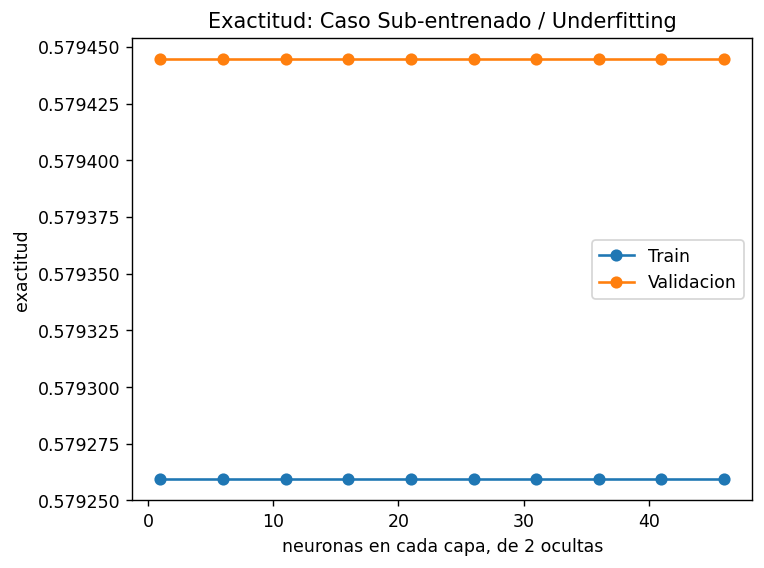

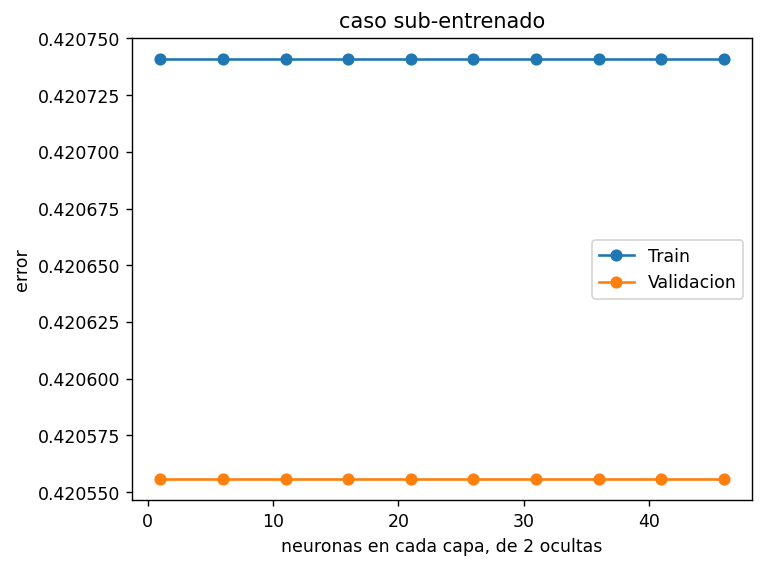

In [27]:
for i in neuronas:
    model = MLPClassifier(hidden_layer_sizes=(i, i),
                          max_iter=3000,
                          alpha=50,
                          random_state=42)
    model.fit(x_train, y_train)

    #predicciones y metricas con el conjunto de entrenamiento
    train_yhat = model.predict(x_train)
    train_loss = np.mean(abs(y_train - train_yhat))
    train_errors.append(train_loss)
    train_acc = 1 - train_loss
    train_scores.append(train_acc)

    #predicciones y metricas con el conjunto de validacion
    valid_yhat = model.predict(x_validation)
    valid_loss = np.mean(abs(y_validation - valid_yhat))
    valid_errors.append(valid_loss)
    valid_acc = 1 - valid_loss
    valid_scores.append(valid_acc)

    #evolucion de las metricas durante el entrenamiento
    print("> %d...\ttrainacc: %.3f, validacc: %.3f, trainloss: %.3f, validloss: %.3f"
          % (i, train_acc, valid_acc, train_loss, valid_loss))

plt.plot(neuronas, train_scores, "-o", label="Train")
plt.plot(neuronas, valid_scores, "-o", label="Validacion")
plt.legend()
plt.title("Exactitud: Caso Sub-entrenado / Underfitting")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("exactitud")
plt.show()

plt.plot(neuronas, train_errors, "-o", label="Train")
plt.plot(neuronas, valid_errors, "-o", label="Validacion")
plt.legend()
plt.title("caso sub-entrenado")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("error")
plt.show()

con alpha=50 la exactitud queda en 0.579 en entrenamiento y validacion con cualquier cantidad de neuronas. las curvas son planas y estan bajas, es el caso sub-entrenado, los pesos se van a cero y la red no aprende

In [28]:
"""caso sobre-entrenado: alpha pequeno (0.15)"""
print("alpha=0.15")
train_scores, valid_scores = list(), list()
train_errors, valid_errors = list(), list()

alpha=0.15


> 1...	trainacc: 0.580, validacc: 0.581, trainloss: 0.420, validloss: 0.419
> 6...	trainacc: 0.863, validacc: 0.836, trainloss: 0.137, validloss: 0.164
> 11...	trainacc: 0.894, validacc: 0.832, trainloss: 0.106, validloss: 0.168
> 16...	trainacc: 0.909, validacc: 0.829, trainloss: 0.091, validloss: 0.171
> 21...	trainacc: 0.919, validacc: 0.832, trainloss: 0.081, validloss: 0.168
> 26...	trainacc: 0.929, validacc: 0.834, trainloss: 0.071, validloss: 0.166
> 31...	trainacc: 0.959, validacc: 0.839, trainloss: 0.041, validloss: 0.161
> 36...	trainacc: 0.961, validacc: 0.829, trainloss: 0.039, validloss: 0.171
> 41...	trainacc: 0.958, validacc: 0.834, trainloss: 0.042, validloss: 0.166
> 46...	trainacc: 0.969, validacc: 0.827, trainloss: 0.031, validloss: 0.173


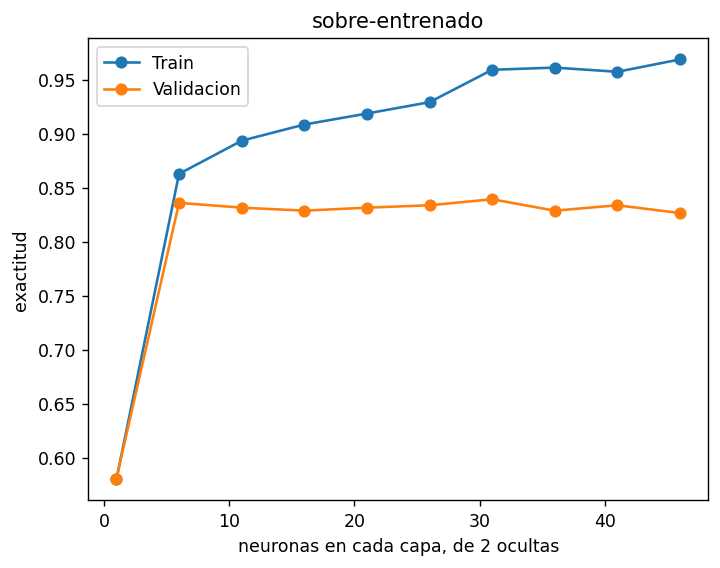

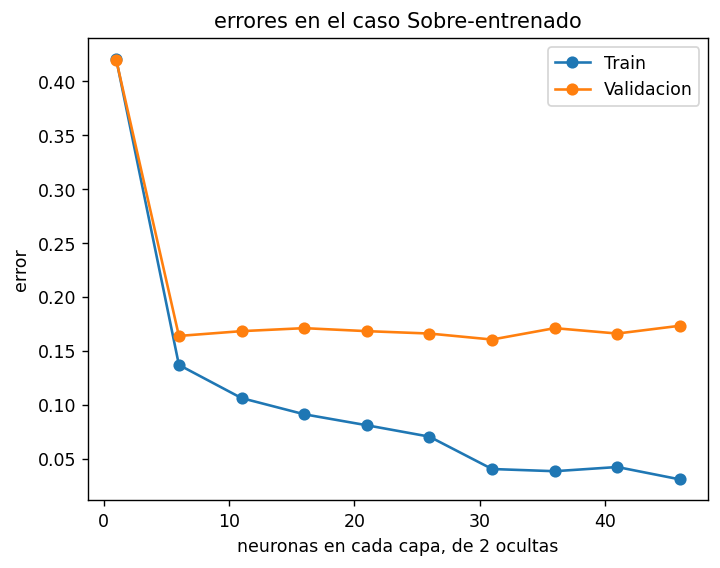

In [29]:
for i in neuronas:
    model = MLPClassifier(hidden_layer_sizes=(i, i),
                          max_iter=3000,
                          alpha=0.15,
                          random_state=42)

    model.fit(x_train, y_train)

    #predicciones y metricas con el conjunto de entrenamiento
    train_yhat = model.predict(x_train)
    train_loss = np.mean(abs(y_train - train_yhat))
    train_errors.append(train_loss)
    train_acc = 1 - train_loss
    train_scores.append(train_acc)

    #predicciones y metricas con el conjunto de validacions
    valid_yhat = model.predict(x_validation)
    valid_loss = np.mean(abs(y_validation - valid_yhat))
    valid_errors.append(valid_loss)
    valid_acc = 1 - valid_loss
    valid_scores.append(valid_acc)

    #evolucion de las metricas durante el entrenamiento
    print("> %d...\ttrainacc: %.3f, validacc: %.3f, trainloss: %.3f, validloss: %.3f"
          % (i, train_acc, valid_acc, train_loss, valid_loss))

plt.plot(neuronas, train_scores, "-o", label="Train")
plt.plot(neuronas, valid_scores, "-o", label="Validacion")
plt.legend()
plt.title("sobre-entrenado")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("exactitud")
plt.show()

plt.plot(neuronas, train_errors, "-o", label="Train")
plt.plot(neuronas, valid_errors, "-o", label="Validacion")
plt.legend()
plt.title("errores en el caso Sobre-entrenado")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("error")
plt.show()

cuando el valor de alpha es 0.15 la exactitud de entrenamiento sube de 0.86 a 0.97 al aumentar las neuronas, pero la de validacion se queda entre 0.83 y 0.84. el modelo memoriza el entrenamiento el caso sobre entrenado

In [30]:
"""busqueda del mejor ajuste con alpha intermedio las dos curvas crecen juntas.."""
print("alpha=0.7")
train_scores, valid_scores = list(), list()
train_errors, valid_errors = list(), list()

alpha=0.7


> 1...	trainacc: 0.579, validacc: 0.579, trainloss: 0.421, validloss: 0.421
> 6...	trainacc: 0.863, validacc: 0.831, trainloss: 0.137, validloss: 0.169
> 11...	trainacc: 0.875, validacc: 0.851, trainloss: 0.125, validloss: 0.149
> 16...	trainacc: 0.884, validacc: 0.833, trainloss: 0.116, validloss: 0.167
> 21...	trainacc: 0.895, validacc: 0.851, trainloss: 0.105, validloss: 0.149
> 26...	trainacc: 0.897, validacc: 0.834, trainloss: 0.103, validloss: 0.166
> 31...	trainacc: 0.896, validacc: 0.842, trainloss: 0.104, validloss: 0.158
> 36...	trainacc: 0.908, validacc: 0.838, trainloss: 0.092, validloss: 0.162
> 41...	trainacc: 0.904, validacc: 0.848, trainloss: 0.096, validloss: 0.152
> 46...	trainacc: 0.912, validacc: 0.841, trainloss: 0.088, validloss: 0.159


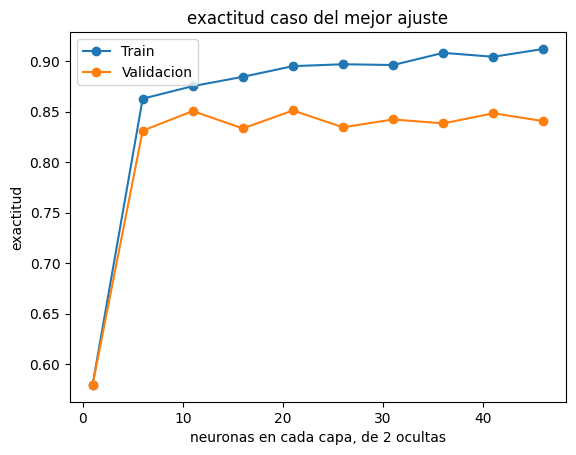

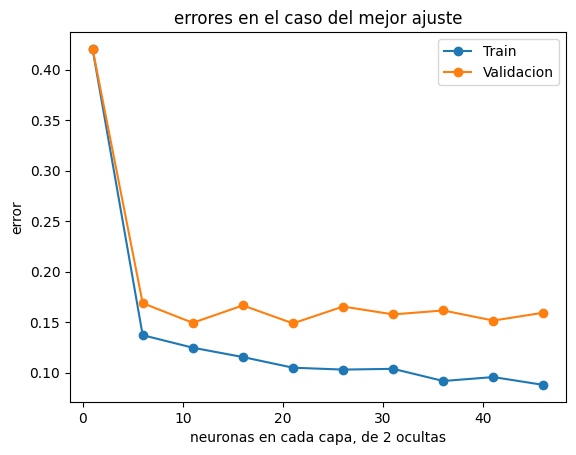

In [31]:
for i in neuronas:
    model = MLPClassifier(hidden_layer_sizes=(i, i),
                          max_iter=1000,
                          alpha=0.7,
                          random_state=42)
    model.fit(x_train, y_train)

    #predicciones y metricas con el conjunto de entrenamiento
    train_yhat = model.predict(x_train)
    train_loss = np.mean(abs(y_train - train_yhat))
    train_errors.append(train_loss)
    train_acc = 1 - train_loss
    train_scores.append(train_acc)

    #predicciones y metricas con el conjunto de validacion
    valid_yhat = model.predict(x_validation)
    valid_loss = np.mean(abs(y_validation - valid_yhat))
    valid_errors.append(valid_loss)
    valid_acc = 1 - valid_loss
    valid_scores.append(valid_acc)

    #evolucion de las metricas durante el entrenamiento
    print("> %d...\ttrainacc: %.3f, validacc: %.3f, trainloss: %.3f, validloss: %.3f"
          % (i, train_acc, valid_acc, train_loss, valid_loss))

plt.plot(neuronas, train_scores, "-o", label="Train")
plt.plot(neuronas, valid_scores, "-o", label="Validacion")
plt.legend()
plt.title("exactitud caso del mejor ajuste")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("exactitud")
plt.show()

plt.plot(neuronas, train_errors, "-o", label="Train")
plt.plot(neuronas, valid_errors, "-o", label="Validacion")
plt.legend()
plt.title("errores en el caso del mejor ajuste")
plt.xlabel("neuronas en cada capa, de 2 ocultas")
plt.ylabel("error")
plt.show()

In [32]:
"""busqueda de alpha y neuronas"""
resultados_NN = []
for alpha in [0.7, 1.0, 3.0, 10.0]:
    for i in neuronas:
        model = MLPClassifier(hidden_layer_sizes=(i, i), max_iter=1000, alpha=alpha, random_state=42)
        model.fit(x_train, y_train)
        tr, va = model.score(x_train, y_train), model.score(x_validation, y_validation)
        resultados_NN.append((alpha, i, tr, va))
        print(f"alpha={alpha}, neuronas={i}: train={tr:.3f}, validacion={va:.3f}")

alpha=0.7, neuronas=1: train=0.579, validacion=0.579
alpha=0.7, neuronas=6: train=0.863, validacion=0.831
alpha=0.7, neuronas=11: train=0.875, validacion=0.851
alpha=0.7, neuronas=16: train=0.884, validacion=0.833
alpha=0.7, neuronas=21: train=0.895, validacion=0.851
alpha=0.7, neuronas=26: train=0.897, validacion=0.834
alpha=0.7, neuronas=31: train=0.896, validacion=0.842
alpha=0.7, neuronas=36: train=0.908, validacion=0.838
alpha=0.7, neuronas=41: train=0.904, validacion=0.848
alpha=0.7, neuronas=46: train=0.912, validacion=0.841
alpha=1.0, neuronas=1: train=0.579, validacion=0.579
alpha=1.0, neuronas=6: train=0.853, validacion=0.832
alpha=1.0, neuronas=11: train=0.871, validacion=0.851
alpha=1.0, neuronas=16: train=0.869, validacion=0.838
alpha=1.0, neuronas=21: train=0.879, validacion=0.841
alpha=1.0, neuronas=26: train=0.884, validacion=0.844
alpha=1.0, neuronas=31: train=0.881, validacion=0.850
alpha=1.0, neuronas=36: train=0.890, validacion=0.847
alpha=1.0, neuronas=41: train=0.

In [33]:
res_NN = pd.DataFrame(resultados_NN, columns=["alpha", "neuronas", "train", "validacion"])
display(res_NN.sort_values("validacion", ascending=False).head(5))

mejor = res_NN.sort_values("validacion", ascending=False).iloc[0]
mejor_alpha, mejor_neuronas = mejor["alpha"], int(mejor["neuronas"])
print("mejor alpha:", mejor_alpha, "- mejor neuronas por capa:", mejor_neuronas)

,alpha,neuronas,train,validacion
4,0.7,21,0.895000,0.851111
12,1.0,11,0.871481,0.851111
2,0.7,11,0.875185,0.850556
16,1.0,31,0.880556,0.850000
8,0.7,41,0.904259,0.848333


mejor alpha: 0.7 - mejor neuronas por capa: 21


cuando tengo que (alpha=0.7) las curvas de entrenamiento y validacion crecen cerca una de la otra por eso es el mejor ajuste. alpha mas grande (entre 3-10) vuelve a bajar la validacion a 0.82 y 0.80 por que empieza el sub-entrenamiento, entonces el mejor en validacion es (alpha=0.7) con 21 neuronas por capa (0.8511) el cual empata con (alpha=1.0) con 11 neuronas, la exactitud de entrenamiento baja respecto al sobre-entrenado y eso es normal

In [34]:
"""busqueda del numero de capas ocultas"""
resultados_capas = []
for capas in [1, 2, 3, 4]:
    arquitectura = tuple([mejor_neuronas] * capas)
    model = MLPClassifier(hidden_layer_sizes=arquitectura, max_iter=1000, alpha=mejor_alpha, random_state=42)
    model.fit(x_train, y_train)
    tr, va = model.score(x_train, y_train), model.score(x_validation, y_validation)
    resultados_capas.append((capas, arquitectura, tr, va))
    print(f"capas={capas} {arquitectura}: train={tr:.3f}, validacion={va:.3f}")

res_capas = pd.DataFrame(resultados_capas, columns=["capas", "arquitectura", "train", "validacion"])
mejor_arquitectura = res_capas.sort_values(["validacion", "capas"], ascending=[False, True]).iloc[0]["arquitectura"]
print("mejor arquitectura:", mejor_arquitectura)

capas=1 (21,): train=0.859, validacion=0.838
capas=2 (21, 21): train=0.895, validacion=0.851
capas=3 (21, 21, 21): train=0.919, validacion=0.843
capas=4 (21, 21, 21, 21): train=0.932, validacion=0.834
mejor arquitectura: (21, 21)


In [35]:
modelo_NN = MLPClassifier(hidden_layer_sizes=mejor_arquitectura,
                          max_iter=1000, alpha=mejor_alpha, random_state=42)
modelo_NN.fit(x_train, y_train)

print("red neuronal ajustada: exactitud validacion =", modelo_NN.score(x_validation, y_validation))
print(confusion_matrix(y_validation, modelo_NN.predict(x_validation)))

red neuronal ajustada: exactitud validacion = 0.8511111111111112
[[881 162]
 [106 651]]


# ------------------- seleccion del mejor modelo con validacion

In [36]:
modelos = {"regresion logistica": modelo_RL, "red neuronal": modelo_NN}
exactitudes = {}

regresion logistica
exactitud con validacion = 0.8238888888888889
[[893 150]
 [167 590]]
VN=893, FP=150, FN=167, VP=590
red neuronal
exactitud con validacion = 0.8511111111111112
[[881 162]
 [106 651]]
VN=881, FP=162, FN=106, VP=651


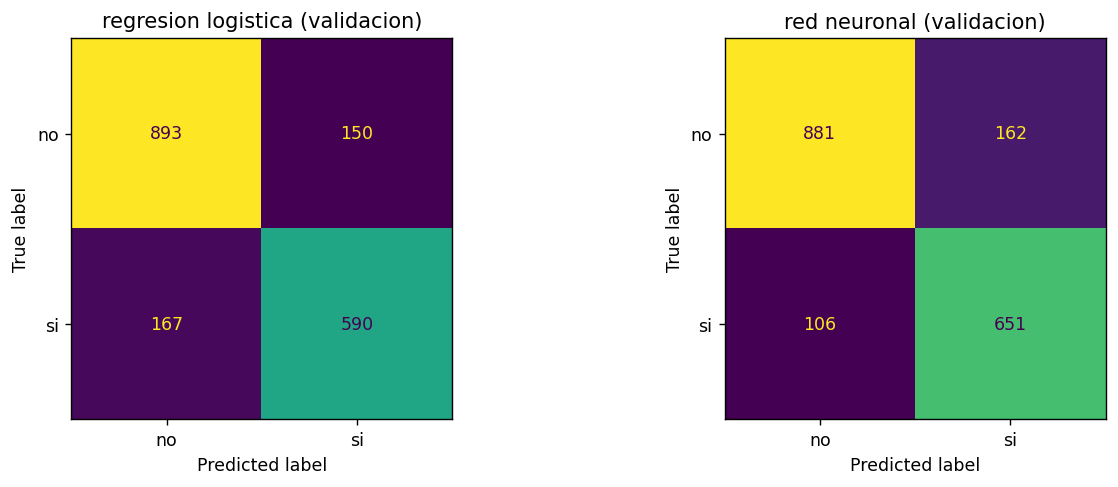

mejor modelo: red neuronal


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    acc_valid = modelo.score(x_validation, y_validation)
    pr = modelo.predict(x_validation)
    cm = confusion_matrix(y_validation, pr)
    vn, fp, fn, vp = cm.ravel()
    exactitudes[nombre] = acc_valid

    print(nombre)
    print("exactitud con validacion =", acc_valid)
    print(cm)
    print(f"VN={vn}, FP={fp}, FN={fn}, VP={vp}")

    ConfusionMatrixDisplay(cm, display_labels=["no", "si"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{nombre} (validacion)")
plt.tight_layout()
plt.show()

mejor_nombre = max(exactitudes, key=exactitudes.get)
mejor_modelo = modelos[mejor_nombre]
print("mejor modelo:", mejor_nombre)

# ------------------- matriz de confusion y evaluacion con el conjunto de prueba

red neuronal
exactitud con prueba = 0.86
[[894 148]
 [104 654]]
VN=894, FP=148, FN=104, VP=654


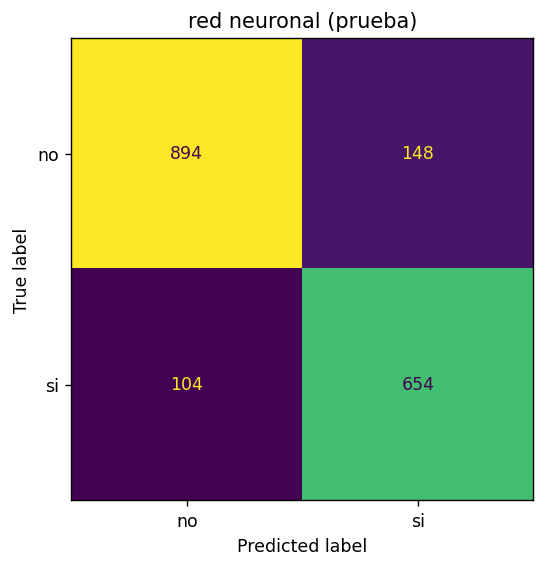

In [38]:
"""el conjunto de prueba solo se usa con el mejor modelo"""
acc_test = mejor_modelo.score(x_test, y_test)
cm = confusion_matrix(y_test, mejor_modelo.predict(x_test))
vn, fp, fn, vp = cm.ravel()

print(mejor_nombre)
print("exactitud con prueba =", acc_test)
print(cm)
print(f"VN={vn}, FP={fp}, FN={fn}, VP={vp}")

ConfusionMatrixDisplay(cm, display_labels=["no", "si"]).plot(colorbar=False)
plt.title(f"{mejor_nombre} (prueba)")
plt.show()

In [39]:
resumen = pd.DataFrame({
    "modelo": ["modelo inicial base", "regresion logistica", "red nueronal"],
    "exactitud_validacion": [modelo_base, exactitudes["regresion logistica"], exactitudes["red neuronal"]],
})


display(resumen.round(4))

,modelo,exactitud_validacion
0,modelo inicial base,0.5792
1,regresion logistica,0.8239
2,red nueronal,0.8511


# ------------------- cual es el mejor modelo

1. ambos modelos superan por mucho al modelo inicial base de 57.9 de exactitud
    2. regresion logistica con (saga, l1, C=8.75): 82.4 en validacion y 83.6 en prueba y la matriz de confusion en prueba: 896 VN, 146 FP, 149 FN y 609 VP.
    3. red neuronal con (2 capas de 21 neuronas, alpha=0.7): 85.1 en validacion y 86 en prueba y la matriz de confusion en prueba: 894 VN, 148 FP, 104 FN y 654 VP.

el mejor modelo es la red neuronal, la razon es porque tiene mayor exactitud en validacion y en prueba y su exactitud en prueba no baja respecto a validacion lo que quiere decir que generaliza bien y no memoriza
- la exactitud sola no basta y hay que ver los errores de la matriz de confusion
- la clase positiva es que el cliente si adquiere el plan
    - un falso positivo (FP) es considerar a alguien que no va a comprar. 
    - un falso negativo (FN) es basicamente olvidar a un cliente que si iba a comprar el plan, esto se traduce a la perdida de una venta

- falsos positivos de la regresion logistica = 146, y la red neuronal = 148;
- falsos negativos de la regresion logistica 149, y la red neuronal 104;
